[ 39.93853958 -21.71398427  39.92702319  -9.1243164  629.99427873]
-0.017803206520403216


In [56]:
import math
import numpy as np
import matplotlib.pyplot as plt
from Scripts.drone_mass import DroneMass
from Scripts.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.beams import BeamType
from Scripts.drone_fea import DroneFEA
import Scripts.unit_conversions as uc
from scipy.optimize import NonlinearConstraint
import scipy
from matplotlib.lines import Line2D

# np.array([Failure_Constraint, Deflection_Constraint, Natural_Frequency_Lower_Constraint, Natural_Frequency_Upper_Constraint, lb1, lb2,lb3,lb4,lb5, ub1, ub2, ub3, ub4, ub5])
Active_Constraints = np.array([1,9,11])

Initial_Guess = np.array([0.45,   0.6, 0.45,     0.8, 0.6 ])
Scaling_Factor = np.array([100,1,100,1,1000])

stress_FOS = 4
allowable_deflection = 50.0 # mm
nf_clearence = 1.2

drag_coeff = 0.256
Propeller_RPM = 3068
Propeller_Forcing_Function_Hz = Propeller_RPM / 30
Propeller_Forcing_Function_Rad = Propeller_Forcing_Function_Hz * uc.Hz_to_rad_per_s
Propeller_radius = 406.4
Propeller_spacing = 25
arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)

battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))

def failure_constraint(x):
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]

    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    d1_fea.beam_system.add_force(np.array([0,0,-66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.solve_static()
    d1_fea.solve_failure()

    Failure_Constraint = d1_fea.beam_system.max_failure_crit * stress_FOS

    return Failure_Constraint


def deflection_constraint(x):
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]

    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    d1_fea.beam_system.add_force(np.array([0,0,-66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.solve_static()

    max_disp = max(d1_fea.beam_system.mag_displacements)

    Deflection_Constraint =  max_disp / allowable_deflection

    return Deflection_Constraint

def mass(x):
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]
    # Beam properties
    # arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
    # strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

    # Drone geometry
    # drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    drone_mass = DroneMass(drone_geometry)

    return drone_mass.lumped_mass_frame

def mass_gradient(x, h):
    h_mat = np.identity(5) * h
    x_mat = np.stack([x] * 5)
    x_ph = x_mat + h_mat
    x_mh = x_mat - h_mat
    m_ph = np.zeros([5])
    m_mh = np.zeros([5])
    for i in range(5):
        m_ph[i] = mass(x_ph[i])
        m_mh[i] = mass(x_mh[i])
    m_g = (m_ph - m_mh) / (2 * h)
    
    return m_g


def natural_frequency_upper_constraint(x):
    arm_d1,arm_t, strut_d1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]
    # Beam properties
    # arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
    # strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")


    # Drone geometry
    # drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    
    # FEA
    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    # d1_fea.beam_system.add_force(np.array([0,0,66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.beam_system.solve_natural_frequencies()

    Natural_Frequencies_Hz = d1_fea.beam_system.natural_frequencies/(2*math.pi)
    Natural_Frequency_Upper_Constraint = Propeller_Forcing_Function_Hz / (Natural_Frequencies_Hz[2] * nf_clearence)

    return Natural_Frequency_Upper_Constraint


def natural_frequency_lower_constraint(x):
    arm_r1,arm_t,strut_r1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]
    # Beam properties
    # arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
    # strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
    arm_beam_properties = BeamType("annulus", [arm_r1 + arm_t*2, arm_r1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_r1 + strut_t*2, strut_r1 ], "Carbon Fiber", "strut_beam")


    # Drone geometry
    # drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    # FEA
    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    d1_fea.solve_fea()
    d1_fea.beam_system.solve_natural_frequencies()

    Natural_Frequencies_Hz = d1_fea.beam_system.natural_frequencies/(2*math.pi)
    Natural_Frequency_Lower_Constraint = nf_clearence * Natural_Frequencies_Hz[1] / Propeller_Forcing_Function_Hz

    return Natural_Frequency_Lower_Constraint




def calc_constraints(x, all):
    arm_r1,arm_t,strut_r1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]

    arm_beam_properties = BeamType("annulus", [arm_r1 + arm_t*2, arm_r1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_r1 + strut_t*2, strut_r1 ], "Carbon Fiber", "strut_beam")
    
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() 
    d1_fea.create_drone_slice_beams() 
    d1_fea.boundary_conditions_slice()
    d1_fea.beam_system.add_force(np.array([0,0,-66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.beam_system.solve_natural_frequencies()
    d1_fea.solve_static()
    d1_fea.solve_failure()

    max_disp = max(d1_fea.beam_system.mag_displacements)
    Natural_Frequencies_Hz = d1_fea.beam_system.natural_frequencies/(2*math.pi)

    Failure_Constraint = d1_fea.beam_system.max_failure_crit * stress_FOS - 1
    Deflection_Constraint =  max_disp / allowable_deflection - 1
    Natural_Frequency_Lower_Constraint = nf_clearence * Natural_Frequencies_Hz[1] / Propeller_Forcing_Function_Hz - 1
    Natural_Frequency_Upper_Constraint = Propeller_Forcing_Function_Hz / (Natural_Frequencies_Hz[2] * nf_clearence) - 1
    
    lb1 = (10 - arm_r1)/100
    lb2 = 0.25 - arm_t
    lb3 = (10 - strut_r1)/100
    lb4 = 0.25 - strut_t
    lb5 = (100 - strut_dist)/1000

    ub1 = (-50 + arm_r1)/100
    ub2 = -3.75 + arm_t
    ub3 = (-50 + strut_r1)/100
    ub4 = -3.75 + strut_t
    ub5 = (-1500 + strut_dist)/1000
    if all:
        return np.array([Failure_Constraint, Deflection_Constraint, Natural_Frequency_Lower_Constraint, Natural_Frequency_Upper_Constraint, lb1, lb2,lb3,lb4,lb5, ub1, ub2, ub3, ub4, ub5])
    else:
        # Returns the subset of active constraints
        return np.array([Failure_Constraint, Deflection_Constraint, Natural_Frequency_Lower_Constraint, Natural_Frequency_Upper_Constraint, lb1, lb2,lb3,lb4,lb5, ub1, ub2, ub3, ub4, ub5])[Active_Constraints]

    


def calc_constraint_jacobians(x, h):
    cons_num = len(Active_Constraints)
    c_jac = np.zeros(cons_num)
    h_mat = np.identity(5) * h
    x_mat = np.stack([x] * 5)
    x_ph = x_mat + h_mat
    x_mh = x_mat - h_mat
    c_ph = np.zeros([5,cons_num])
    c_mh = np.zeros([5,cons_num])
    for i in range(5):
        c_ph[i] = calc_constraints(x_ph[i],False)
        c_mh[i] = calc_constraints(x_mh[i],False)
    c_jac = (c_ph - c_mh) / (2 * h)

    return np.transpose(c_jac)

def test_constraints(x):
    return np.array([failure_constraint(x),
                     deflection_constraint(x),
                     natural_frequency_lower_constraint(x),
                     natural_frequency_upper_constraint(x),
                     mass(x)])


def vis_design_space(x_var, y_var, bounds, section, p,x_list):
    var_x_val = section[x_var]
    var_y_val = section[y_var]

    failure_grd = np.zeros([p, p])
    deflection_grd = np.zeros([p, p])
    nf_low_grd = np.zeros([p, p])
    nf_upper_grd = np.zeros([p, p])
    mass_grd = np.zeros([p, p])

    bounds_ext = [bounds[x_var][0], bounds[x_var][1], bounds[y_var][0], bounds[y_var][1]]

    X_space = np.linspace(bounds[x_var][0], bounds[x_var][1], p)
    Y_space = np.linspace(bounds[y_var][0], bounds[y_var][1], p)

    for x_i, x in enumerate(X_space):
        for y_i, y in enumerate(Y_space):
            test_point = section.copy()
            test_point[x_var] = x / Scaling_Factor[x_var]
            test_point[y_var] = y / Scaling_Factor[y_var]
            failure_grd[y_i, x_i] = failure_constraint(test_point) 
            deflection_grd[y_i, x_i] = deflection_constraint(test_point) 
            nf_low_grd[y_i, x_i] = natural_frequency_lower_constraint(test_point) 
            nf_upper_grd[y_i, x_i] = natural_frequency_upper_constraint(test_point) 
            mass_grd[y_i, x_i] = mass(test_point) * 1000  # kg

    plt.figure(figsize=(10, 10))
    img = plt.imshow(mass_grd, cmap='turbo', interpolation='nearest', extent=bounds_ext, origin='lower')

    cbar = plt.colorbar(img)
    cbar.set_ticks(np.linspace(np.min(mass_grd), np.max(mass_grd), num=5))
    cbar.set_label('Mass (kg)')

    xv, yv = np.meshgrid(X_space, Y_space)
    lvls = np.array([1.0, 1.1])
    line_widths = [3,1]

    contours0 = plt.contour(xv, yv, failure_grd, levels=lvls, linewidths = [4,1], colors='g')
    contours1 = plt.contour(xv, yv, deflection_grd, levels=lvls, linewidths = line_widths,colors='y')
    contours3 = plt.contour(xv, yv, nf_upper_grd, levels=lvls, linewidths = line_widths,colors='b')
    contours2 = plt.contour(xv, yv, nf_low_grd, levels=lvls, linewidths = line_widths,colors='m')

    plt.clabel(contours0, inline=True, fontsize=8, fmt='%1.3f')
    plt.clabel(contours1, inline=True, fontsize=8, fmt='%1.3f')
    plt.clabel(contours2, inline=True, fontsize=8, fmt='%1.3f')
    plt.clabel(contours3, inline=True, fontsize=8, fmt='%1.3f')

    plt.gca().set_aspect('auto', adjustable='box')

    legend_elements = [
        Line2D([0], [0], color='g', lw=2, label='Failure Constraint'),
        Line2D([0], [0], color='y', lw=2, label='Deflection Constraint'),
        Line2D([0], [0], color='b', lw=2, label='Natural Frequency Upper'),
        Line2D([0], [0], color='m', lw=2, label='Natural Frequency Lower')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.scatter(var_x_val * Scaling_Factor[x_var], var_y_val * Scaling_Factor[y_var], c='r')
    if x_list is not None:
        plt.scatter(x_list[0:-1,x_var] * Scaling_Factor[x_var], x_list[0:-1,y_var] * Scaling_Factor[y_var], c='k')
        plt.scatter(x_list[0,x_var] * Scaling_Factor[x_var], x_list[0,y_var] * Scaling_Factor[y_var], c='b')


def find_feasible_point(initial_guess, h, max_iter, e):
    x = initial_guess.copy()
    for i in range(max_iter):
        c = calc_constraints(x,False)
        if np.linalg.norm(c) < e:
            return x
        J = calc_constraint_jacobians(x,h)
        JTJ = np.transpose(J) @ J
        JTc = np.transpose(J) @ c
        J = calc_constraint_jacobians(x, h)
        delta_x = np.linalg.lstsq(JTJ , -JTc)[0]
        x += delta_x
        print(i)




def sqp(xi, h, max_iter, tol, R):
    x_list = [xi]
    x = xi
    Q = np.eye(len(x))
    steps = 0
    for iteration in range(max_iter):
        grad_f = mass_gradient(x, h)
        c = calc_constraints(x,False)
        c_len = len(c)
        J = calc_constraint_jacobians(x, h)
        
        KKT = np.block([
            [Q, np.transpose(J)],
            [J, np.zeros((len(J), len(J)))]
        ])
        vector_kkt = np.concatenate([-grad_f,-c])
        
        KKT_sol = np.linalg.solve(KKT, vector_kkt)
        d =  KKT_sol[:len(x)]
        # Step Size Calculation Equal Section Search
        Interval_Size = 50
        x_p = np.double(x)
        x_u = np.double(x + Interval_Size * d)
        x_a = np.double(0)
        x_b = np.double(0)
        
        while Interval_Size > 1e-12:
            x_a = x_u * (1/3) + x_p * (2/3)
            x_b = x_u * (2/3) + x_p * (1/3)
            V_a = np.max(np.abs(calc_constraints(x_a,False)))
            V_b = np.max(np.abs(calc_constraints(x_b,False)))
            f_a = np.double(mass(x_a) + (V_a ** 2) * R) 
            f_b = np.double(mass(x_b) + (V_b ** 2) * R)
            if f_a < f_b:
                x_u = x_b
            else:
                x_p = x_a
            Interval_Size = np.linalg.norm(x_u - x_p)
            
        if np.linalg.norm(x_p - x) < tol:
            print("Iterations: ", iteration)
            break
            
        
        x = x_p
        x_list.append(x_p)
        steps = iteration





    return x, mass(x), np.array(x_list), steps 


Initial_SQP = find_feasible_point(Initial_Guess,1e-12,50,1e-6)
Results_x, Mass_x, x_list, steps = sqp(Initial_SQP,1e-12,500,1e-12,0.2)

print(f'- Initial Guess -')
print(f'arm inner radius: {Initial_Guess[0]*Scaling_Factor[0]} mm')
print(f'arm thickness: {Initial_Guess[1]*Scaling_Factor[1]} mm')
print(f'strut inner radius: {Initial_Guess[2]*Scaling_Factor[2]} mm')
print(f'strut thickness: {Initial_Guess[3]*Scaling_Factor[3]} mm')
print(f'strut distance: {Initial_Guess[4]*Scaling_Factor[4]} mm')
print(f'Mass: {mass(Initial_Guess) * 1000} kg')
print(f'Constraints met: {calc_constraints(Initial_Guess,True)}')

print(f'- Initial Guess SQP-')
print(f'arm inner radius: {Initial_SQP[0]*Scaling_Factor[0]} mm')
print(f'arm thickness: {Initial_SQP[1]*Scaling_Factor[1]} mm')
print(f'strut inner radius: {Initial_SQP[2]*Scaling_Factor[2]} mm')
print(f'strut thickness: {Initial_SQP[3]*Scaling_Factor[3]} mm')
print(f'strut distance: {Initial_SQP[4]*Scaling_Factor[4]} mm')
print(f'Mass: {mass(Initial_SQP) * 1000} kg')
print(f'Constraints met: {calc_constraints(Initial_SQP,True)}')

print(f'- Optimized Result -')
print(f'Steps:  {steps}')
print(f'arm inner radius: {Results_x[0]*Scaling_Factor[0]} mm')
print(f'arm thickness: {Results_x[1]*Scaling_Factor[1]} mm')
print(f'strut inner radius: {Results_x[2]*Scaling_Factor[2]} mm')
print(f'strut thickness: {Results_x[3]*Scaling_Factor[3]} mm')
print(f'strut distance: {Results_x[4]*Scaling_Factor[4]} mm')
print(f'Mass: {Mass_x * 1000} kg')
print(f'Constraints met: {calc_constraints(Results_x,True)}')



Boundaries = np.array([[3, 60], [0.25, 3.175], [3, 60], [0.25, 3.175], [100, 1500]])
'''
vis_design_space(0,1,Boundaries,np.array(Results_x),30,x_list)
plt.title('Constraints')
plt.xlabel('arm inner radius (mm)')
plt.ylabel('arm thickness(mm)')
plt.show()

vis_design_space(2,3,Boundaries,np.array(Results_x),30,x_list)
plt.title('Constraints')
plt.xlabel('strut inner radius (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

vis_design_space(2,4,Boundaries,np.array(Results_x),30,x_list)
plt.title('Constraints')
plt.xlabel('strut inner radius (mm)')
plt.ylabel('strut distance (mm)')
plt.show()
'''

C:\Users\natha\AppData\Local\Temp\ipykernel_2460\1067182014.py:308: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  delta_x = np.linalg.lstsq(JTJ , -JTc)[0]


0
1
2
3
4
Iterations:  8
- Initial Guess -
arm inner radius: 45.0 mm
arm thickness: 0.6 mm
strut inner radius: 45.0 mm
strut thickness: 0.8 mm
strut distance: 600.0 mm
Mass: 1.4591218011823104 kg
Constraints met: [-0.25462405 -0.16321269 -0.35914594 -0.07937308 -0.35       -0.35
 -0.35       -0.55       -0.5        -0.05       -3.15       -0.05
 -2.95       -0.9       ]
- Initial Guess SQP-
arm inner radius: 50.0 mm
arm thickness: 0.3349941628747865 mm
strut inner radius: 50.0 mm
strut thickness: 0.6506050018664169 mm
strut distance: 524.9673868127287 mm
Mass: 0.9871272997613953 kg
Constraints met: [-6.57188100e-02 -2.59249597e-08 -3.97503722e-01 -1.48126212e-01
 -4.00000000e-01 -8.49941629e-02 -4.00000000e-01 -4.00605002e-01
 -4.24967387e-01  0.00000000e+00 -3.41500584e+00  0.00000000e+00
 -3.09939500e+00 -9.75032613e-01]
- Optimized Result -
Steps:  7
arm inner radius: 49.999999999999986 mm
arm thickness: 0.339061989905344 mm
strut inner radius: 50.0 mm
strut thickness: 0.64537238643

"\nvis_design_space(0,1,Boundaries,np.array(Results_x),30,x_list)\nplt.title('Constraints')\nplt.xlabel('arm inner radius (mm)')\nplt.ylabel('arm thickness(mm)')\nplt.show()\n\nvis_design_space(2,3,Boundaries,np.array(Results_x),30,x_list)\nplt.title('Constraints')\nplt.xlabel('strut inner radius (mm)')\nplt.ylabel('strut thickness (mm)')\nplt.show()\n\nvis_design_space(2,4,Boundaries,np.array(Results_x),30,x_list)\nplt.title('Constraints')\nplt.xlabel('strut inner radius (mm)')\nplt.ylabel('strut distance (mm)')\nplt.show()\n"

In [57]:
## VERIFICATION ## 


Initial_Guess = np.array([0.45, 1, 0.45, 1, 0.400])

Constraints = (
    NonlinearConstraint(deflection_constraint, 0, 1),
    NonlinearConstraint(failure_constraint, 0, 1)
)

Boundaries = np.array([[0.03, 0.50], [0.25, 3.175], [0.03, 0.50], [0.25, 3.175], [0.1, 1.5]])

Results = scipy.optimize.minimize(mass,Initial_Guess,bounds=Boundaries,constraints=Constraints,tol=1e-10)

Boundaries_2 = np.array([[3, 50], [0.25, 3.175], [3, 50], [0.25, 3.175], [100, 1500]])
print(Results)
print("Initial Guess:")
print("arm radius | arm thickness | strut radius | strut thickness | strut dist from center")
print(Initial_Guess)
print("failure | deflection | mass")
print(test_constraints(Initial_Guess))
print("Mass (kg)", mass(Initial_Guess) * 1000)

print("\n")

print("Optimized:")
print("arm radius | arm thickness | strut radius | strut thickness | strut dist from center")
print(np.round(Results.x,decimals=5))
print("failure | deflection | mass")
print(test_constraints(Results.x))
print("Mass (kg)", mass(Results.x) * 1000)




 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0009848341061748798
       x: [ 5.000e-01  3.627e-01  5.000e-01  6.099e-01  4.904e-01]
     nit: 40
     jac: [ 1.251e-03  1.750e-03  7.007e-04  5.885e-04  7.231e-04]
    nfev: 242
    njev: 40
Initial Guess:
arm radius | arm thickness | strut radius | strut thickness | strut dist from center
[0.45 1.   0.45 1.   0.4 ]
failure | deflection | mass
[0.45596353 0.59732353 0.60762817 0.76463192 0.00201835]
Mass (kg) 2.0183537429640745


Optimized:
arm radius | arm thickness | strut radius | strut thickness | strut dist from center
[0.5     0.36265 0.5     0.60986 0.4904 ]
failure | deflection | mass
[9.05931749e-01 1.00000000e+00 6.02148118e-01 8.33754764e-01
 9.84834106e-04]
Mass (kg) 0.9848341061748799


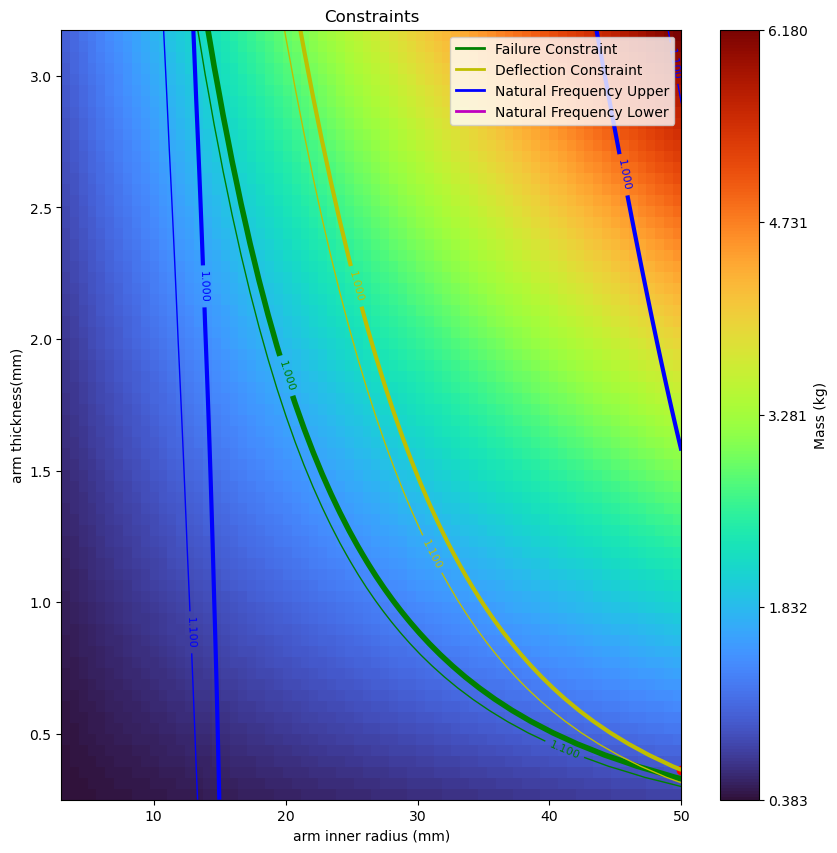

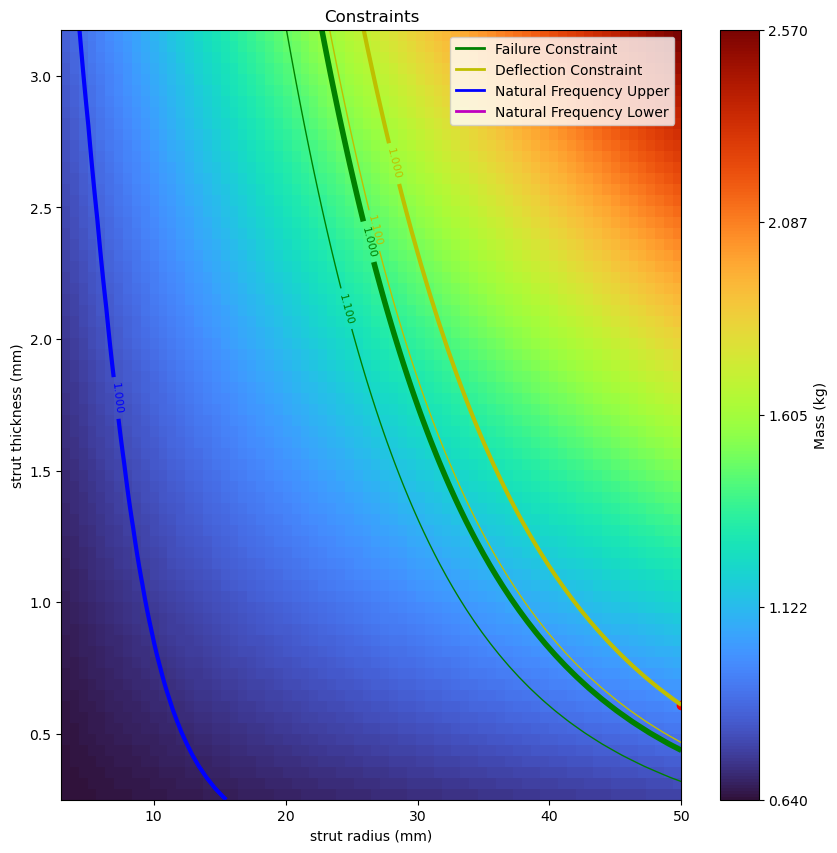

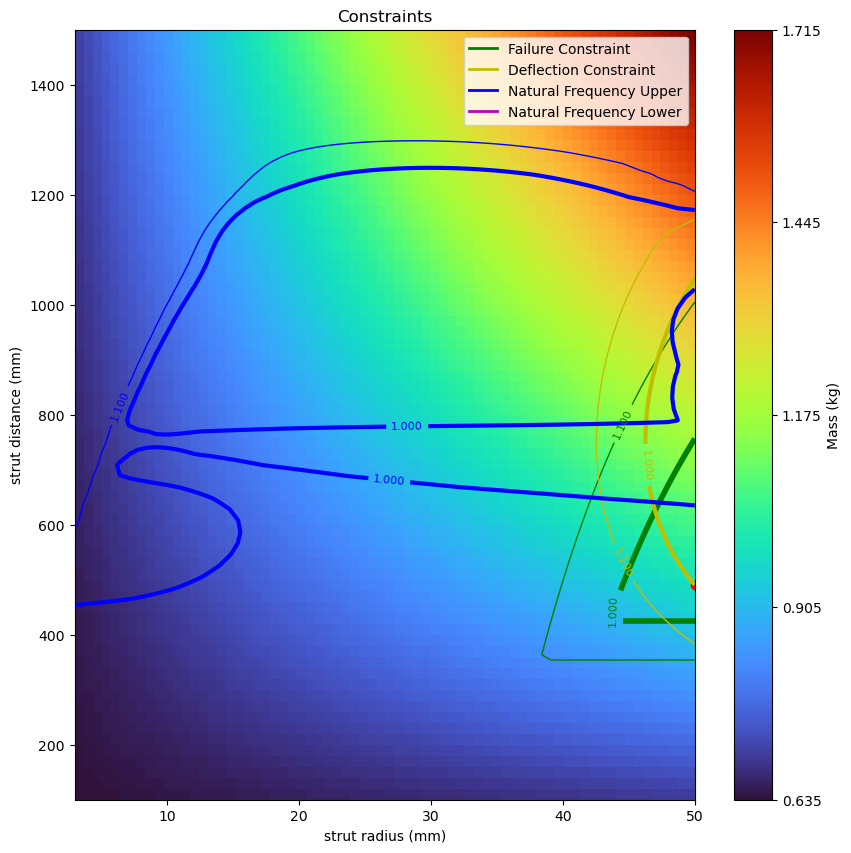

In [58]:
vis_design_space(0,1,Boundaries_2,np.array(Results.x),70,None)
plt.title('Constraints')
plt.xlabel('arm inner radius (mm)')
plt.ylabel('arm thickness(mm)')
plt.show()

vis_design_space(2,3,Boundaries_2,np.array(Results.x),70,None)
plt.title('Constraints')
plt.xlabel('strut radius (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

vis_design_space(2,4,Boundaries_2,np.array(Results.x),70,None)
plt.title('Constraints')
plt.xlabel('strut radius (mm)')
plt.ylabel('strut distance (mm)')
plt.show()

In [63]:
print(calc_constraints([0.5,     0.36265, 0.5,     0.60986, 0.4904 ],True))

[-9.40557172e-02  8.85781841e-06 -3.97851546e-01 -1.66248464e-01
 -4.00000000e-01 -1.12650000e-01 -4.00000000e-01 -3.59860000e-01
 -3.90400000e-01  0.00000000e+00 -3.38735000e+00  0.00000000e+00
 -3.14014000e+00 -1.00960000e+00]
